In [2]:
!pip install dcm2niix --quiet

In [14]:
!pip install pydicom --quiet

# Checks

In [18]:
"""
ADNI amyloid PET inventory — PARALLEL version. Reads every image from its
ORIGINAL path and reports format, time-frames, slices, matrix size. NO conversion.
Requires: pip install pydicom nibabel
"""
import pydicom, json
from pathlib import Path
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed

SRC_DIRS = ["AMY_PET_1", "AMY_PET_2"]
N_WORKERS = 6

def fmt_of(folder):
    exts = {f.suffix.lower() for f in folder.iterdir() if f.is_file()}
    if ".dcm" in exts: return "dicom"
    if ".v"   in exts: return "ecat"
    if ".i" in exts or ".hdr" in exts: return "interfile"
    return "unknown"

def profile_folder(path_str):
    """Runs in a worker process. Returns one record dict per image folder."""
    folder = Path(path_str)
    fmt = fmt_of(folder)
    rec = {"id": folder.name, "fmt": fmt, "path": path_str}
    if fmt != "dicom":
        return rec
    try:
        dcms = list(folder.glob("*.dcm"))
        hdrs = [pydicom.dcmread(str(p), stop_before_pixels=True,
                                specific_tags=["AcquisitionTime", "FrameReferenceTime",
                                               "Rows", "Columns"])
                for p in dcms]
        times = set()
        for h in hdrs:
            t = getattr(h, "AcquisitionTime", None) or getattr(h, "FrameReferenceTime", None)
            times.add(str(t))
        nf = len(times)
        mat = (int(getattr(hdrs[0], "Rows", 0)), int(getattr(hdrs[0], "Columns", 0)))
        tot = len(dcms)
        spf = tot / nf if nf else tot
        rec.update(n_frames=nf, slices_per_frame=spf, matrix=mat,
                   total_files=tot, clean=float(spf).is_integer())
    except Exception as e:
        rec.update(error=str(e)[-80:])
    return rec

if __name__ == "__main__":
    leaves = [str(p) for src in SRC_DIRS for p in Path(src).rglob("I*")
              if p.is_dir() and not any(c.is_dir() for c in p.iterdir())]
    print(f"Total image folders: {len(leaves)}  |  workers: {N_WORKERS}\n")

    rows, done = [], 0
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        futs = [ex.submit(profile_folder, p) for p in leaves]
        for f in as_completed(futs):
            rows.append(f.result())
            done += 1
            if done % 200 == 0:
                print(f"  {done}/{len(leaves)} processed")

    # ---- report ----
    fmt_counter = Counter(r["fmt"] for r in rows)
    print("\n=== FORMAT BREAKDOWN ===")
    for k, v in fmt_counter.items(): print(f"  {k:10s}: {v}")

    dcm = [r for r in rows if r["fmt"] == "dicom" and "n_frames" in r]
    print(f"\n=== DICOM TIME-FRAME BREAKDOWN ({len(dcm)} images) ===")
    print("  frames -> count:", dict(sorted(Counter(r["n_frames"] for r in dcm).items())))

    print("\n=== DICOM MATRIX SIZES ===")
    print("  ", dict(Counter(r["matrix"] for r in dcm)))

    incomplete = [r for r in dcm if not r["clean"]]
    print(f"\n=== INCOMPLETE (files not divisible by frames): {len(incomplete)} ===")
    for r in incomplete[:15]:
        print(f"  {r['id']}: {r['total_files']} files / {r['n_frames']} frames "
              f"= {r['slices_per_frame']:.2f}")

    errs = [r for r in rows if "error" in r]
    print(f"\n=== READ ERRORS: {len(errs)} ===")
    for r in errs[:10]: print(f"  {r['id']}: {r['error']}")

    Path("inventory.json").write_text(json.dumps(rows, default=str))
    print(f"\nSaved {len(rows)} records to inventory.json")

Total image folders: 1499  |  workers: 6

  200/1499 processed
  400/1499 processed
  600/1499 processed
  800/1499 processed
  1000/1499 processed
  1200/1499 processed
  1400/1499 processed

=== FORMAT BREAKDOWN ===
  dicom     : 1138
  interfile : 126
  ecat      : 235

=== DICOM TIME-FRAME BREAKDOWN (1138 images) ===
  frames -> count: {1: 8, 2: 97, 3: 2, 4: 1030, 6: 1}

=== DICOM MATRIX SIZES ===
   {(192, 192): 161, (400, 400): 154, (440, 440): 60, (128, 128): 449, (336, 336): 236, (360, 360): 1, (256, 256): 17, (168, 168): 60}

=== INCOMPLETE (files not divisible by frames): 2 ===
  I346272: 182 files / 4 frames = 45.50
  I1533408: 545 files / 2 frames = 272.50

=== READ ERRORS: 0 ===

Saved 1499 records to inventory.json


# Convert

In [20]:
"""
PASS 1 — CONVERSION ONLY (no averaging).
Converts all raw amyloid PET (DICOM / ECAT / Interfile) to .nii.gz,
keeping temporal frames intact. Parallelized with threads (subprocess-bound).
Requires: dcm2niix and i2nii on PATH.
Output: every image as <I-number>*.nii.gz in OUT_DIR.
"""
import subprocess, json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

SRC_DIRS  = ["AMY_PET_1", "AMY_PET_2"]
OUT_DIR   = Path("amy_nii_raw"); OUT_DIR.mkdir(exist_ok=True)
N_WORKERS = 6

def fmt_of(folder):
    exts = {f.suffix.lower() for f in folder.iterdir() if f.is_file()}
    if ".dcm" in exts: return "dicom"
    if ".v"   in exts: return "ecat"
    if ".i" in exts or ".hdr" in exts: return "interfile"
    return "unknown"

def convert(folder):
    """Convert one image folder. Returns (id, status)."""
    iid = folder.name
    fmt = fmt_of(folder)
    try:
        if fmt == "dicom":
            # default run keeps frames (as 4D file or split siblings)
            subprocess.run(["dcm2niix","-z","y","-b","n","-f",iid,"-o",str(OUT_DIR),str(folder)],
                           capture_output=True, text=True)
            if not list(OUT_DIR.glob(f"{iid}*.nii.gz")):
                # retry forcing a merged single volume
                subprocess.run(["dcm2niix","-z","y","-b","n","-m","y","-f",iid,
                                "-o",str(OUT_DIR),str(folder)], capture_output=True, text=True)
        else:  # ecat or interfile
            src = next(f for f in folder.iterdir()
                       if f.suffix.lower() in {".v", ".hdr"})
            subprocess.run(["i2nii","-z","y","-o",str(OUT_DIR),str(src)],
                           capture_output=True, text=True)
            # i2nii names output after the input file -> rename to I-number
            for p in OUT_DIR.glob(f"{src.stem}*.nii.gz"):
                p.rename(OUT_DIR / f"{iid}.nii.gz")

        outs = list(OUT_DIR.glob(f"{iid}*.nii.gz"))
        if   len(outs) == 0: return (iid, "FAIL")
        elif len(outs) >  1: return (iid, "SPLIT")
        else:                return (iid, "OK")
    except Exception as e:
        return (iid, f"ERR:{str(e)[-60:]}")

if __name__ == "__main__":
    leaves = [p for src in SRC_DIRS for p in Path(src).rglob("I*")
              if p.is_dir() and not any(c.is_dir() for c in p.iterdir())]
    print(f"Converting {len(leaves)} images with {N_WORKERS} workers...\n")

    results, done = {}, 0
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        futs = [ex.submit(convert, lf) for lf in leaves]
        for f in as_completed(futs):
            iid, status = f.result()
            results[iid] = status
            done += 1
            if done % 200 == 0:
                print(f"  {done}/{len(leaves)} done")

    from collections import Counter
    print("\n=== CONVERSION OUTCOMES ===")
    for k, v in Counter(results.values()).items():
        print(f"  {k:8s}: {v}")

    print("\nSPLIT and FAIL ids (Pass 2 will consolidate these):")
    print("  SPLIT:", [i for i,s in results.items() if s=="SPLIT"][:20])
    print("  FAIL :", [i for i,s in results.items() if s=="FAIL"])

    Path("pass1_results.json").write_text(json.dumps(results))
    print(f"\nSaved outcomes to pass1_results.json | files in {OUT_DIR}/")

Converting 1499 images with 6 workers...

  200/1499 done
  400/1499 done
  600/1499 done
  800/1499 done
  1000/1499 done
  1200/1499 done
  1400/1499 done

=== CONVERSION OUTCOMES ===
  OK      : 1241
  SPLIT   : 122
  FAIL    : 136

SPLIT and FAIL ids (Pass 2 will consolidate these):
  SPLIT: ['I11343367', 'I10324138', 'I11090406', 'I11076787', 'I11301190', 'I11161748', 'I11221588', 'I11359776', 'I11221587', 'I415248', 'I414827', 'I1080182', 'I194500', 'I380743', 'I394392', 'I229519', 'I244260', 'I1159000', 'I241410', 'I502273']
  FAIL : ['I361577', 'I1173813', 'I412657', 'I407292', 'I1266492', 'I661530', 'I281629', 'I1190349', 'I971796', 'I1064393', 'I317458', 'I500344', 'I395009', 'I622320', 'I722844', 'I864613', 'I346272', 'I259488', 'I192279', 'I377985', 'I192160', 'I733776', 'I314608', 'I279593', 'I409816', 'I272450', 'I316583', 'I356184', 'I1058602', 'I215687', 'I496331', 'I372942', 'I488610', 'I662467', 'I291371', 'I416513', 'I311731', 'I379161', 'I541368', 'I429825', 'I68960

In [21]:
"""Diagnose Pass 1 FAILs: what format are they, and what does i2nii actually output?"""
import json, subprocess
from pathlib import Path

SRC_DIRS = ["AMY_PET_1", "AMY_PET_2"]
OUT_DIR  = Path("amy_nii_raw")
results  = json.loads(Path("pass1_results.json").read_text())
fails    = [i for i, s in results.items() if s == "FAIL"]

# map id -> folder path
leaves = {p.name: p for src in SRC_DIRS for p in Path(src).rglob("I*")
          if p.is_dir() and not any(c.is_dir() for c in p.iterdir())}

def fmt_of(folder):
    exts = {f.suffix.lower() for f in folder.iterdir() if f.is_file()}
    if ".dcm" in exts: return "dicom"
    if ".v"   in exts: return "ecat"
    if ".i" in exts or ".hdr" in exts: return "interfile"
    return "unknown"

# 1) what formats are the failures?
from collections import Counter
fail_fmts = Counter(fmt_of(leaves[i]) for i in fails if i in leaves)
print("FAIL formats:", dict(fail_fmts))

# 2) take ONE ecat/interfile fail and run i2nii verbosely to see what it does
for i in fails:
    f = leaves.get(i)
    if f and fmt_of(f) in {"ecat", "interfile"}:
        src = next(x for x in f.iterdir() if x.suffix.lower() in {".v", ".hdr"})
        print(f"\n--- trying i2nii on {i} ({fmt_of(f)}) ---")
        print("source file:", src.name)
        r = subprocess.run(["i2nii", "-z", "y", "-o", str(OUT_DIR), str(src)],
                           capture_output=True, text=True)
        print("STDOUT:", r.stdout[-300:])
        print("STDERR:", r.stderr[-300:])
        print("files now matching stem:", list(OUT_DIR.glob(f"{src.stem}*")))
        print("files now matching id  :", list(OUT_DIR.glob(f"{i}*")))
        break

# 3) list what IS in the folder of that fail
print("\nfolder contents:", [x.name for x in f.iterdir()][:10])

FAIL formats: {'interfile': 126, 'ecat': 9, 'dicom': 1}

--- trying i2nii on I361577 (interfile) ---
source file: ADNI_053_S_5070_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20130228085314171_S183352_I361577.i.hdr
STDOUT: _053_S_5070_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20130228085314171.i"
Interfile error "main body" 
Unable to interpret header "AMY_PET_2/ADNI/053_S_5070/ADNI_Brain_PET__Raw_AV45/2013-02-21_14_46_23.0/I361577/ADNI_053_S_5070_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20130228085314171_S183352_I361577.i.hdr"

STDERR: 
files now matching stem: []
files now matching id  : []

folder contents: ['ADNI_053_S_5070_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20130228085314171_S183352_I361577.i.hdr', 'ADNI_053_S_5070_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20130228085308562_S183352_I361577.i', 'ADNI_053_S_5070_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20130228085317218_S183352_I361577.i.hdr', 'ADNI_053_S_5070_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20130228085314171_S183352_I361577.i', 'ADNI_053_S_5070_PET_ADNI_Bra

In [22]:
"""Find the working i2nii invocation for Interfile frames."""
import json, subprocess
from pathlib import Path

SRC_DIRS = ["AMY_PET_1", "AMY_PET_2"]
OUT = Path("amy_nii_raw")
results = json.loads(Path("pass1_results.json").read_text())
fails = [i for i, s in results.items() if s == "FAIL"]
leaves = {p.name: p for src in SRC_DIRS for p in Path(src).rglob("I*")
          if p.is_dir() and not any(c.is_dir() for c in p.iterdir())}

def is_interfile(f):
    e = {x.suffix.lower() for x in f.iterdir() if x.is_file()}
    return ".i" in e or ".hdr" in e

inter_fails = [i for i in fails if i in leaves and is_interfile(leaves[i])]
print(f"Interfile fails: {len(inter_fails)}\n")

# test 3 of them: try converting a single .i frame two ways
tested = 0
for iid in inter_fails:
    folder = leaves[iid]
    i_files   = sorted(folder.glob("*.i"))          # the data frames
    hdr_files = sorted(folder.glob("*.i.hdr"))       # the headers
    print(f"=== {iid}: {len(i_files)} .i frames, {len(hdr_files)} headers ===")

    frame = i_files[0]
    # Attempt A: point i2nii at the .i data file
    rA = subprocess.run(["i2nii","-o","/tmp",str(frame)], capture_output=True, text=True)
    outA = list(Path("/tmp").glob(f"{frame.stem}*.nii*"))
    print(f"  [.i ] {'OK '+outA[0].name if outA else 'FAIL'} | {rA.stdout[-90:].strip()}")

    # Attempt B: point i2nii at the matching .hdr
    hdr = Path(str(frame) + ".hdr")
    rB = subprocess.run(["i2nii","-o","/tmp",str(hdr)], capture_output=True, text=True) if hdr.exists() else None
    outB = list(Path("/tmp").glob(f"{hdr.stem}*.nii*")) if rB else []
    print(f"  [hdr] {'OK '+outB[0].name if outB else 'FAIL'}"
          + (f" | {rB.stdout[-90:].strip()}" if rB else " (no .hdr)"))

    tested += 1
    if tested >= 3: break

Interfile fails: 126

=== I361577: 4 .i frames, 4 headers ===
  [.i ] FAIL | /ADNI_053_S_5070_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20130228085308562_S183352_I361577.i"
  [hdr] FAIL | I_053_S_5070_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20130228085308562_S183352_I361577.i.hdr"
=== I1173813: 4 .i frames, 4 headers ===
  [.i ] FAIL | 3813/ADNI_032_S_6709_PET_ADNI_Brain_PET__Raw_br_raw_20190606162137380_S830833_I1173813.i"
  [hdr] FAIL | /ADNI_032_S_6709_PET_ADNI_Brain_PET__Raw_br_raw_20190606162137380_S830833_I1173813.i.hdr"
=== I412657: 4 .i frames, 4 headers ===
  [.i ] FAIL | /ADNI_128_S_0138_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20140205121928989_S211904_I412657.i"
  [hdr] FAIL | I_128_S_0138_PET_ADNI_Brain_PET__Raw_AV45_br_raw_20140205121928989_S211904_I412657.i.hdr"


In [28]:
"""
Convert ALL Interfile (.i/.hdr) ADNI PET images directly with numpy — no medcon.
Reads each frame from its .hdr + .i, stacks frames into a 4D volume,
builds an affine from the header voxel spacing, saves <I-number>.nii.gz.
Frames are kept (averaging is Pass 2), matching the DICOM outputs.

Run wherever the Interfile folders are (server or local). Set SRC accordingly.
"""
import numpy as np
import nibabel as nib
from pathlib import Path
import re, json

# point this at the folder containing the Interfile I-number folders
SRC = Path("to_convert_locally")          # or the server path
OUT = Path("amy_nii_raw"); OUT.mkdir(exist_ok=True)

def hget(txt, key):
    m = re.search(rf"{re.escape(key)}\s*:=\s*(.+)", txt)
    return m.group(1).strip() if m else None

def read_interfile_frame(hdr_path):
    txt = Path(hdr_path).read_text(errors="ignore")
    nx, ny, nz = (int(hget(txt, f"matrix size [{i}]")) for i in (1, 2, 3))
    nbytes = int(hget(txt, "number of bytes per pixel"))
    numfmt = hget(txt, "number format").lower()
    dtype = {"float": np.float32}.get(numfmt, np.float32)
    if numfmt == "float" and nbytes == 8: dtype = np.float64
    # voxel spacing (mm)
    sx, sy, sz = (float(hget(txt, f"scaling factor (mm/pixel) [{i}]")) for i in (1, 2, 3))
    data_file = Path(str(hdr_path)[:-4])           # ".i.hdr" -> ".i"
    raw = np.fromfile(str(data_file), dtype=dtype)
    arr = raw.reshape((nz, ny, nx))                # z, y, x
    return arr, (sx, sy, sz)

def is_interfile(folder):
    e = {x.suffix.lower() for x in folder.iterdir() if x.is_file()}
    return ".i" in e or ".hdr" in e

folders = [p for p in SRC.iterdir() if p.is_dir() and is_interfile(p)]
print(f"{len(folders)} Interfile images to convert\n")

ok, bad = [], []
for folder in folders:
    iid = folder.name
    try:
        headers = sorted(folder.glob("*.i.hdr"))
        frames, spacing = [], None
        for h in headers:
            arr, sp = read_interfile_frame(h)
            frames.append(arr); spacing = sp
        vol = np.stack(frames, axis=-1) if len(frames) > 1 else frames[0]
        # reorder to x,y,z(,t) for NIfTI convention
        vol = np.moveaxis(vol, [0,1,2], [2,1,0])   # z,y,x -> x,y,z
        # affine from voxel spacing
        sx, sy, sz = spacing
        affine = np.diag([sx, sy, sz, 1.0])
        nib.save(nib.Nifti1Image(vol.astype(np.float32), affine),
                 OUT / f"{iid}.nii.gz")
        ok.append(iid)
    except Exception as e:
        bad.append((iid, str(e)[-100:]))

print(f"Converted: {len(ok)} | Failed: {len(bad)}")
for x in bad[:20]: print("  ", x)
Path("interfile_done.json").write_text(json.dumps({"ok": ok, "bad": bad}))
print(f"\nSaved to {OUT}/  (4D, frames preserved — Pass 2 will average)")

126 Interfile images to convert

Converted: 126 | Failed: 0

Saved to amy_nii_raw/  (4D, frames preserved — Pass 2 will average)


In [31]:
from pathlib import Path
import re

# all stems
stems = [f.name.replace(".nii.gz", "") for f in Path("amy_nii_raw").glob("*.nii.gz")]
print("Total files on disk:", len(stems))

# which stems DON'T match the clean I-number or I-number+letter pattern?
weird = [s for s in stems if not re.match(r"^I\d+[a-c]?$", s)]
print("Non-standard names:", len(weird))
for w in weird[:30]:
    print("  ", w)

Total files on disk: 1682
Non-standard names: 20
   ADNI_024_S_2239_PET_Dy1_[F-18]AV-45_4i_16s__br_raw_20211021144903614_S1074999_I1507334
   ADNI_024_S_2239_PET_[F-18]AV-45_Dy1_4i_16s__AV45_br_raw_20141120081239750_S237107_I454211
   I1039469f
   I1595518e
   I1623152e
   ADNI_024_S_5290_PET_Dy1_[F-18]AV-45_4i_16s__br_raw_20190909152102701_S871528_I1224609
   ADNI_024_S_5290_PET_Dy1_[F-18]AV-45_4i_16s__br_raw_20170912070521988_S607209_I902339
   ADNI_024_S_4084_PET_[F-18]_20_min_4i_16s__AV45_br_raw_20150804093322754_S267783_I503678
   ADNI_024_S_2239_PET_Dy1_[F-18]AV-45_4i_16s__br_raw_20170329142405664_S550034_I834315
   I1039469g
   ADNI_024_S_4674_PET_Dy1_[F-18]AV-45_4i_16s__br_raw_20170627151338189_S575477_I864613
   I1533408d
   I1039469e
   I1623152d
   I1039469d
   ADNI_024_S_4674_PET_[F-18]AV-45_Dy1_4i_16s__br_raw_20160602142707253_S454230_I722844
   I1595518d
   I1595066d
   I1595066e
   ADNI_024_S_4169_PET_[F-18]AV-45_Dy1_4i_16s__AV45_br_raw_20150908075854390_S272068_I509381


In [32]:
from pathlib import Path
import re

files = list(Path("amy_nii_raw").glob("*.nii.gz"))
print("Total files:", len(files))

def true_id(stem):
    # find the I-number anywhere in the name (handles both I12345 and long ADNI names)
    m = re.search(r"(I\d+)", stem)
    return m.group(1) if m else stem

ids = {}
for f in files:
    stem = f.name.replace(".nii.gz", "")
    iid = true_id(stem)
    ids.setdefault(iid, []).append(f.name)

print("Unique TRUE image IDs:", len(ids), "(target 1499)")

# which IDs have multiple files (siblings or duplicates)?
multi = {k: v for k, v in ids.items() if len(v) > 1}
print("IDs with multiple files:", len(multi))

Total files: 1682
Unique TRUE image IDs: 1498 (target 1499)
IDs with multiple files: 122


In [33]:
from pathlib import Path
import re, json

# all target ids from the original inventory
inv = json.loads(Path("inventory.json").read_text())
target_ids = {r["id"] for r in inv}        # all 1499 expected
print("Target:", len(target_ids))

# what we actually have
files = list(Path("amy_nii_raw").glob("*.nii.gz"))
have = set()
for f in files:
    m = re.search(r"(I\d+)", f.name.replace(".nii.gz",""))
    if m: have.add(m.group(1))
print("Have:", len(have))

missing = target_ids - have
print("MISSING:", missing)

Target: 1499
Have: 1498
MISSING: {'I346272'}


In [34]:
import pydicom, numpy as np, nibabel as nib
from pathlib import Path
from collections import defaultdict

# find the original folder for I346272
folder = next(p for src in ["AMY_PET_1","AMY_PET_2"]
              for p in Path(src).rglob("I346272") if p.is_dir())
print("folder:", folder)

slices = [pydicom.dcmread(str(p)) for p in folder.glob("*.dcm")]
print("slices:", len(slices))

# group by spatial position, average the frames at each position
buckets = defaultdict(list)
for s in slices:
    loc = round(float(getattr(s, "SliceLocation", getattr(s, "InstanceNumber", 0))), 1)
    buckets[loc].append(s.pixel_array.astype(np.float32))

locs = sorted(buckets)
print("distinct positions:", len(locs))
print("frames per position:", sorted({len(v) for v in buckets.values()}))

vol = np.stack([np.mean(buckets[l], axis=0) for l in locs], axis=-1)  # (H,W,Z)
print("volume shape:", vol.shape)

nib.save(nib.Nifti1Image(vol, np.eye(4)), Path("amy_nii_raw")/"I346272.nii.gz")
print("saved I346272.nii.gz")

folder: AMY_PET_2/ADNI/021_S_2100/PET_3D_BRAIN_ITERATIVE_AV45/2012-11-08_14_43_00.0/I346272
slices: 182
distinct positions: 47
frames per position: [3, 4]
volume shape: (128, 128, 47)
saved I346272.nii.gz


In [35]:
from pathlib import Path
import re, json

# all target ids from the original inventory
inv = json.loads(Path("inventory.json").read_text())
target_ids = {r["id"] for r in inv}        # all 1499 expected
print("Target:", len(target_ids))

# what we actually have
files = list(Path("amy_nii_raw").glob("*.nii.gz"))
have = set()
for f in files:
    m = re.search(r"(I\d+)", f.name.replace(".nii.gz",""))
    if m: have.add(m.group(1))
print("Have:", len(have))

missing = target_ids - have
print("MISSING:", missing)

Target: 1499
Have: 1499
MISSING: set()


# Collapse 4D --> 3D

In [36]:
from pathlib import Path
import re

RAW = Path("amy_nii_raw")
files = list(RAW.glob("*.nii.gz"))

def true_id(name):
    return re.search(r"(I\d+)", name).group(1)

groups = {}
for f in files:
    groups.setdefault(true_id(f.name), []).append(f)

print("Unique images:", len(groups))

# breakdown: how many images come from 1 file vs multiple (siblings)?
from collections import Counter
sizes = Counter(len(v) for v in groups.values())
print("files-per-image -> count:", dict(sorted(sizes.items())))

Unique images: 1499
files-per-image -> count: {1: 1377, 2: 96, 3: 1, 4: 20, 5: 1, 6: 3, 8: 1}


In [37]:
import nibabel as nib, numpy as np
from pathlib import Path

OUT = Path("amy_nii_static"); OUT.mkdir(exist_ok=True)

def collapse_image(iid, file_list):
    """Return one 3D array for this image, averaging frames/siblings."""
    if len(file_list) == 1:
        img = nib.load(str(file_list[0]))
        arr = img.get_fdata()
        affine = img.affine
        if arr.ndim == 4:                    # single 4D file -> average frames
            arr = arr.mean(axis=3)
        return arr, affine
    else:                                    # multiple sibling files -> average them
        arrs, affine = [], None
        for f in sorted(file_list, key=lambda p: p.name):
            img = nib.load(str(f))
            a = img.get_fdata()
            if a.ndim == 4: a = a.mean(axis=3)
            arrs.append(a)
            affine = img.affine
        # all siblings should share shape; average across them
        return np.mean(np.stack(arrs, axis=0), axis=0), affine

done, bad = [], []
for iid, flist in groups.items():
    try:
        vol, aff = collapse_image(iid, flist)
        assert vol.ndim == 3, f"{iid} not 3D: {vol.shape}"
        nib.save(nib.Nifti1Image(vol.astype(np.float32), aff), OUT / f"{iid}.nii.gz")
        done.append(iid)
    except Exception as e:
        bad.append((iid, str(e)[-100:]))

print(f"Collapsed: {len(done)} | Failed: {len(bad)}")
for x in bad[:20]: print("  ", x)

Collapsed: 1489 | Failed: 10
   ('I1408113', 'all input arrays must have the same shape')
   ('I1572642', 'all input arrays must have the same shape')
   ('I700825', 'all input arrays must have the same shape')
   ('I972181', 'all input arrays must have the same shape')
   ('I502892', 'all input arrays must have the same shape')
   ('I1039469', 'all input arrays must have the same shape')
   ('I996614', 'all input arrays must have the same shape')
   ('I1080182', 'all input arrays must have the same shape')
   ('I1079668', 'all input arrays must have the same shape')
   ('I1154111', 'all input arrays must have the same shape')


In [38]:
import nibabel as nib
from pathlib import Path

for iid in ["I1408113", "I1039469"]:
    print(f"\n=== {iid} ===")
    for f in sorted(groups[iid], key=lambda p: p.name):
        shp = nib.load(str(f)).shape
        print(f"  {f.name}  ->  {shp}")


=== I1408113 ===
  I1408113.nii.gz  ->  (128, 128, 30)
  I1408113a.nii.gz  ->  (128, 128, 31)
  I1408113b.nii.gz  ->  (128, 128, 25)
  I1408113c.nii.gz  ->  (128, 128, 9)

=== I1039469 ===
  I1039469.nii.gz  ->  (336, 336, 81)
  I1039469a.nii.gz  ->  (336, 336, 33)
  I1039469b.nii.gz  ->  (336, 336, 81)
  I1039469c.nii.gz  ->  (336, 336, 81)
  I1039469d.nii.gz  ->  (336, 336, 33)
  I1039469e.nii.gz  ->  (336, 336, 33)
  I1039469f.nii.gz  ->  (336, 336, 81)
  I1039469g.nii.gz  ->  (336, 336, 33)


In [39]:
from pathlib import Path

bad_ids = ['I1408113','I1572642','I700825','I972181','I502892',
           'I1039469','I996614','I1080182','I1079668','I1154111']

leaves = {p.name: p for src in ["AMY_PET_1","AMY_PET_2"]
          for p in Path(src).rglob("I*")
          if p.is_dir() and not any(c.is_dir() for c in p.iterdir())}

for iid in bad_ids:
    folder = leaves.get(iid)
    if folder:
        exts = {f.suffix.lower() for f in folder.iterdir() if f.is_file()}
        n_dcm = len(list(folder.glob("*.dcm")))
        print(f"{iid}: {exts}, {n_dcm} dcm files")
    else:
        print(f"{iid}: FOLDER NOT FOUND")

I1408113: {'.dcm'}, 188 dcm files
I1572642: {'.dcm'}, 188 dcm files
I700825: {'.dcm'}, 188 dcm files
I972181: {'.dcm'}, 188 dcm files
I502892: {'.dcm'}, 188 dcm files
I1039469: {'.dcm'}, 456 dcm files
I996614: {'.dcm'}, 188 dcm files
I1080182: {'.dcm'}, 188 dcm files
I1079668: {'.dcm'}, 188 dcm files
I1154111: {'.dcm'}, 188 dcm files


In [40]:
import pydicom, numpy as np, nibabel as nib
from pathlib import Path
from collections import defaultdict

OUT = Path("amy_nii_static")
bad_ids = ['I1408113','I1572642','I700825','I972181','I502892',
           'I1039469','I996614','I1080182','I1079668','I1154111']

leaves = {p.name: p for src in ["AMY_PET_1","AMY_PET_2"]
          for p in Path(src).rglob("I*")
          if p.is_dir() and not any(c.is_dir() for c in p.iterdir())}

fixed, still_bad = [], []
for iid in bad_ids:
    folder = leaves[iid]
    try:
        slices = [pydicom.dcmread(str(p)) for p in folder.glob("*.dcm")]
        buckets = defaultdict(list)
        for s in slices:
            loc = round(float(getattr(s, "SliceLocation",
                         getattr(s, "InstanceNumber", 0))), 1)
            buckets[loc].append(s.pixel_array.astype(np.float32))
        locs = sorted(buckets)
        vol = np.stack([np.mean(buckets[l], axis=0) for l in locs], axis=-1)
        nib.save(nib.Nifti1Image(vol, np.eye(4)), OUT / f"{iid}.nii.gz")
        fixed.append((iid, vol.shape, sorted({len(v) for v in buckets.values()})))
    except Exception as e:
        still_bad.append((iid, str(e)[-80:]))

print(f"Fixed: {len(fixed)} | Still bad: {len(still_bad)}")
for iid, shp, fpp in fixed:
    print(f"  {iid}: shape {shp}, frames/position {fpp}")
for x in still_bad: print("  FAIL", x)

Fixed: 10 | Still bad: 0
  I1408113: shape (128, 128, 47), frames/position [4]
  I1572642: shape (128, 128, 47), frames/position [4]
  I700825: shape (128, 128, 47), frames/position [4]
  I972181: shape (128, 128, 47), frames/position [4]
  I502892: shape (128, 128, 47), frames/position [4]
  I1039469: shape (336, 336, 114), frames/position [4]
  I996614: shape (128, 128, 47), frames/position [4]
  I1080182: shape (128, 128, 47), frames/position [4]
  I1079668: shape (128, 128, 47), frames/position [4]
  I1154111: shape (128, 128, 47), frames/position [4]


In [41]:
from pathlib import Path
import re

static = list(Path("amy_nii_static").glob("*.nii.gz"))
ids = {re.search(r"(I\d+)", f.name).group(1) for f in static}
print(f"Static volumes: {len(static)} files, {len(ids)} unique IDs (target 1499)")

# verify they're ALL 3D now
import nibabel as nib
ndims = {}
for f in static:
    n = nib.load(str(f)).ndim
    ndims[n] = ndims.get(n, 0) + 1
print("dimensionality:", ndims)

Static volumes: 1499 files, 1499 unique IDs (target 1499)
dimensionality: {3: 1499}


# ============================================================
# PET PREPROCESSING PIPELINE  (step by step)
# Input: amy_nii_static/  (1499 collapsed, orientation-unified 3D volumes)
# Steps: 1) 4mm smooth  2) Y-flip  3) register to FBP template  4) brain mask  5) cerebellar SUVR
# Each step reads the previous step's folder and writes its own.
# ============================================================

## Setup — tools, template, masks, helpers

In [3]:
import sys, subprocess
for pkg in ["antspyx", "nilearn"]:
    try:
        __import__("ants" if pkg == "antspyx" else pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

import os, re, time, json
import numpy as np, nibabel as nib, ants
from scipy.ndimage import gaussian_filter, label, binary_fill_holes, binary_closing
from scipy import ndimage
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt
print("ants:", ants.__version__)

ants: 0.6.3


In [4]:
# MNI grid + brain mask
mni = ants.image_read(ants.get_ants_data("mni"))
MNI_PATH = ants.get_ants_data("mni")
m = mni.numpy()
mask = m > m.max()*0.10
lbl, n = label(mask)
if n > 1:
    sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, n+1))
    mask = lbl == (np.argmax(sizes)+1)
mask = binary_fill_holes(mask); mask = binary_closing(mask, iterations=2)
print("brain mask voxels:", int(mask.sum()))

# FBP template (saved earlier)
template = np.load("fbp_template.npy")
print("FBP template:", template.shape)

# cerebellum mask (AAL 95-120) on template grid
from nilearn import image
aal_img = nib.load("/tmp/aal/AAL3/AAL3v1_1mm.nii.gz")
cereb_native = np.isin(aal_img.get_fdata(), list(range(95,121))).astype(np.float32)
cereb_resampled = image.resample_to_img(nib.Nifti1Image(cereb_native, aal_img.affine),
                                         nib.load(MNI_PATH), interpolation="nearest")
cereb_mask = cereb_resampled.get_fdata() > 0.5
print("cerebellum mask voxels:", int(cereb_mask.sum()))

# save artifacts for worker processes
np.save("_pp_template.npy", template.astype(np.float32))
np.save("_pp_mask.npy", mask.astype(np.uint8))
np.save("_pp_cereb.npy", cereb_mask.astype(np.uint8))
os.environ["MNI_PATH_ENV"] = MNI_PATH


brain mask voxels: 1840910
FBP template: (182, 218, 182)
cerebellum mask voxels: 195313


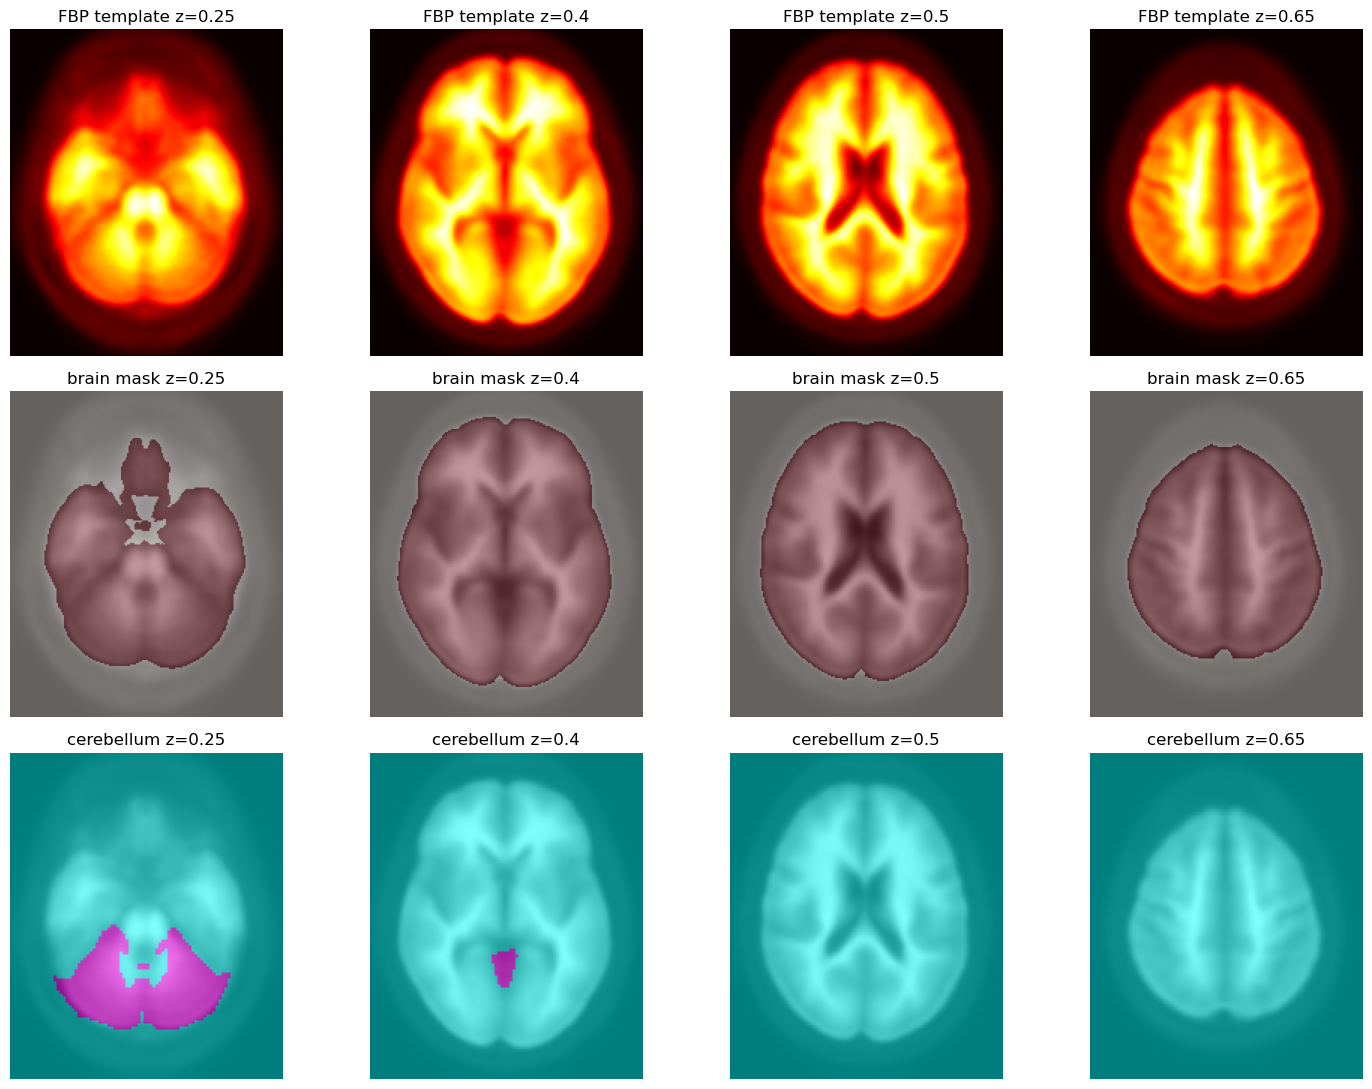

In [5]:
import matplotlib.pyplot as plt, numpy as np

fig, ax = plt.subplots(3, 4, figsize=(15, 11))
nz = template.shape[2]
fracs = [0.25, 0.4, 0.5, 0.65]

# row 0: FBP template
for i, fr in enumerate(fracs):
    z = int(nz*fr)
    ax[0,i].imshow(np.rot90(template[:,:,z]), cmap="hot")
    ax[0,i].set_title(f"FBP template z={fr}"); ax[0,i].axis("off")

# row 1: brain mask on template
for i, fr in enumerate(fracs):
    z = int(nz*fr)
    ax[1,i].imshow(np.rot90(template[:,:,z]), cmap="gray")
    ax[1,i].imshow(np.rot90(mask[:,:,z]), cmap="Reds", alpha=0.4)
    ax[1,i].set_title(f"brain mask z={fr}"); ax[1,i].axis("off")

# row 2: cerebellum mask on template
for i, fr in enumerate(fracs):
    z = int(nz*fr)
    ax[2,i].imshow(np.rot90(template[:,:,z]), cmap="gray")
    ax[2,i].imshow(np.rot90(cereb_mask[:,:,z]), cmap="cool", alpha=0.5)
    ax[2,i].set_title(f"cerebellum z={fr}"); ax[2,i].axis("off")

plt.tight_layout(); plt.show()

In [6]:
def get_id(f): return re.search(r"(I\d+)", Path(f).name).group(1)

def run_parallel(func, in_dir, out_dir, label, workers=6):
    Path(out_dir).mkdir(exist_ok=True)
    paths = [str(f) for f in sorted(Path(in_dir).glob("*.nii.gz"))]
    N = len(paths); done, fail = [], []
    t0 = time.time()
    print(f"[{label}] {N} images: {in_dir}/ -> {out_dir}/\n")
    with ProcessPoolExecutor(max_workers=workers) as ex:
        futs = {ex.submit(func, p): p for p in paths}
        for i, fut in enumerate(as_completed(futs), 1):
            try:
                iid, st = fut.result()
            except Exception as e:
                iid, st = "?", f"ERR {str(e)[-40:]}"
            (done if st in ("ok","skip") else fail).append((iid, st))
            if i % 25 == 0 or i == N:
                el = time.time()-t0
                print(f"  [{i:4d}/{N}] ok={len(done)} fail={len(fail)} | "
                      f"{el:5.0f}s | avg {el/i:4.1f}s | ETA {el/i*(N-i):5.0f}s")
    print(f"\n[{label}] FINISHED. ok/skip={len(done)} fail={len(fail)}")
    for x in fail[:15]: print("   FAIL", x)
    return done, fail

def show_random(folder, title, n=3, seed=0):
    import random
    fs = sorted(Path(folder).glob("*.nii.gz"))
    random.seed(seed); pick = random.sample(fs, min(n, len(fs)))
    fig, ax = plt.subplots(1, len(pick), figsize=(5*len(pick), 5))
    if len(pick) == 1: ax = [ax]
    for a, f in zip(ax, pick):
        v = nib.load(str(f)).get_fdata(); z = v.shape[2]//2
        a.imshow(np.rot90(v[:,:,z]), cmap="hot"); a.set_title(get_id(f)); a.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()


## Step 1 - Smoothing (4 mm FWHM)

In [7]:
def step_smooth(fpath):
    import numpy as np, nibabel as nib, re
    from scipy.ndimage import gaussian_filter
    from pathlib import Path
    iid = re.search(r"(I\d+)", Path(fpath).name).group(1)
    out = Path("pp1_smooth")/f"{iid}.nii.gz"
    if out.exists(): return (iid, "skip")
    img = nib.load(fpath); vox = img.header.get_zooms()[:3]
    sm = gaussian_filter(img.get_fdata(), [(4.0/2.355)/s for s in vox]).astype(np.float32)
    nib.save(nib.Nifti1Image(sm, img.affine), str(out))
    return (iid, "ok")

run_parallel(step_smooth, "amy_nii_static", "pp1_smooth", "SMOOTH")

[SMOOTH] 1499 images: amy_nii_static/ -> pp1_smooth/

  [  25/1499] ok=25 fail=0 |     0s | avg  0.0s | ETA     6s
  [  50/1499] ok=50 fail=0 |     0s | avg  0.0s | ETA     3s
  [  75/1499] ok=75 fail=0 |     0s | avg  0.0s | ETA     2s
  [ 100/1499] ok=100 fail=0 |     0s | avg  0.0s | ETA     2s
  [ 125/1499] ok=125 fail=0 |     0s | avg  0.0s | ETA     1s
  [ 150/1499] ok=150 fail=0 |     0s | avg  0.0s | ETA     1s
  [ 175/1499] ok=175 fail=0 |     0s | avg  0.0s | ETA     1s
  [ 200/1499] ok=200 fail=0 |     0s | avg  0.0s | ETA     1s
  [ 225/1499] ok=225 fail=0 |     0s | avg  0.0s | ETA     1s
  [ 250/1499] ok=250 fail=0 |     0s | avg  0.0s | ETA     1s
  [ 275/1499] ok=275 fail=0 |     0s | avg  0.0s | ETA     1s
  [ 300/1499] ok=300 fail=0 |     0s | avg  0.0s | ETA     0s
  [ 325/1499] ok=325 fail=0 |     0s | avg  0.0s | ETA     0s
  [ 350/1499] ok=350 fail=0 |     0s | avg  0.0s | ETA     0s
  [ 375/1499] ok=375 fail=0 |     0s | avg  0.0s | ETA     0s
  [ 400/1499] ok=40

([('I1002166', 'skip'),
  ('I1002693', 'skip'),
  ('I1012048', 'skip'),
  ('I1007969', 'skip'),
  ('I1015965', 'skip'),
  ('I1004126', 'skip'),
  ('I1016184', 'skip'),
  ('I1008812', 'skip'),
  ('I1010826', 'skip'),
  ('I1018497', 'skip'),
  ('I1020134', 'skip'),
  ('I1020509', 'skip'),
  ('I1021040', 'skip'),
  ('I1021756', 'skip'),
  ('I1023524', 'skip'),
  ('I1021757', 'skip'),
  ('I1023675', 'skip'),
  ('I1024098', 'skip'),
  ('I10241184', 'skip'),
  ('I1025408', 'skip'),
  ('I1025831', 'skip'),
  ('I1026197', 'skip'),
  ('I10293375', 'skip'),
  ('I1029368', 'skip'),
  ('I1029402', 'skip'),
  ('I1029601', 'skip'),
  ('I1028496', 'skip'),
  ('I10315591', 'skip'),
  ('I10315595', 'skip'),
  ('I1032407', 'skip'),
  ('I10324138', 'skip'),
  ('I10355052', 'skip'),
  ('I1036392', 'skip'),
  ('I10364237', 'skip'),
  ('I1037148', 'skip'),
  ('I10376673', 'skip'),
  ('I10376703', 'skip'),
  ('I10379339', 'skip'),
  ('I10388411', 'skip'),
  ('I1039469', 'skip'),
  ('I1039599', 'skip'),
  ('I

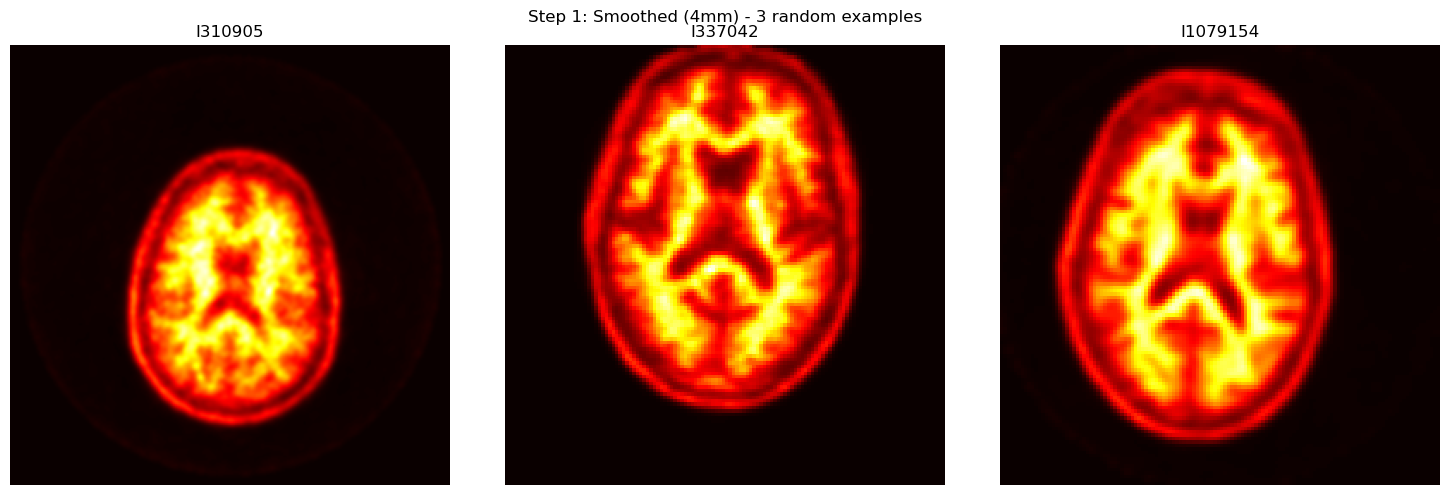

In [8]:
show_random("pp1_smooth", "Step 1: Smoothed (4mm) - 3 random examples")

## Step 2 — Registration to FBP PET template (SyN)

### Worker function

In [9]:
import shutil; shutil.rmtree("pp3_register", ignore_errors=True)
from pathlib import Path
Path("pp3_register").mkdir(exist_ok=True)

def step_register(fpath):
    import os, time
    os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "1"
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    import numpy as np, nibabel as nib, ants, re
    from pathlib import Path
    pid = os.getpid()
    iid = re.search(r"(I\d+)", Path(fpath).name).group(1)
    t0 = time.time()
    print(f"    [pid {pid}] START  {iid}", flush=True)
    out = Path("pp3_register")/f"{iid}.nii.gz"
    if out.exists():
        return (iid, "skip")
    template = np.load("_pp_template.npy")
    mni = ants.image_read(os.environ["MNI_PATH_ENV"])
    template_ants = ants.from_numpy(template, origin=mni.origin,
                                    spacing=mni.spacing, direction=mni.direction)
    img = nib.load(fpath); vox = img.header.get_zooms()[:3]
    moving = ants.from_numpy(img.get_fdata().astype(np.float32),
                             spacing=tuple(float(s) for s in vox))
    reg = ants.registration(fixed=template_ants, moving=moving, type_of_transform="SyN")
    w = reg["warpedmovout"].numpy().astype(np.float32)
    nib.save(nib.Nifti1Image(w, np.eye(4)), str(out))
    print(f"    [pid {pid}] DONE   {iid}  ({time.time()-t0:.0f}s)", flush=True)
    return (iid, "ok")

### Test — single-image registration timing (SyNRA, 1mm)

In [8]:
import time, os
import numpy as np, nibabel as nib, ants, re
from pathlib import Path

template = np.load("_pp_template.npy")
mni = ants.image_read(MNI_PATH)
template_ants = ants.from_numpy(template, origin=mni.origin,
                                spacing=mni.spacing, direction=mni.direction)

f = sorted(Path("pp1_smooth").glob("*.nii.gz"))[0]
print("loaded image, starting registration NOW...", flush=True)

img = nib.load(str(f)); vox = img.header.get_zooms()[:3]
moving = ants.from_numpy(img.get_fdata().astype(np.float32),
                         spacing=tuple(float(s) for s in vox))

t0 = time.time()
reg = ants.registration(fixed=template_ants, moving=moving, type_of_transform="SyNRA")
print(f"ONE registration took {time.time()-t0:.0f}s", flush=True)

loaded image, starting registration NOW...
ONE registration took 104s


### Test — single-image registration timing (SyN, 1mm)

In [9]:
import time, os
import numpy as np, nibabel as nib, ants, re
from pathlib import Path

template = np.load("_pp_template.npy")
mni = ants.image_read(MNI_PATH)
template_ants = ants.from_numpy(template, origin=mni.origin,
                                spacing=mni.spacing, direction=mni.direction)

f = sorted(Path("pp1_smooth").glob("*.nii.gz"))[0]
print("loaded image, starting registration NOW...", flush=True)

img = nib.load(str(f)); vox = img.header.get_zooms()[:3]
moving = ants.from_numpy(img.get_fdata().astype(np.float32),
                         spacing=tuple(float(s) for s in vox))

t0 = time.time()
reg = ants.registration(fixed=template_ants, moving=moving, type_of_transform="SyN")
print(f"ONE registration took {time.time()-t0:.0f}s", flush=True)

loaded image, starting registration NOW...
ONE registration took 75s


### Test — parallelism check (6 images, 6 workers)

In [10]:
import os, time
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

os.environ["MNI_PATH_ENV"] = MNI_PATH
test_paths = [str(f) for f in sorted(Path("pp1_smooth").glob("*.nii.gz"))[:6]]

print("Submitting these 6:")
for p in test_paths: print("   ", Path(p).name)
print(f"\nLaunching 6 workers at {time.strftime('%H:%M:%S')}...\n")

t0 = time.time()
done = 0
with ProcessPoolExecutor(max_workers=6) as ex:
    futs = {ex.submit(step_register, p): p for p in test_paths}
    for fut in as_completed(futs):
        iid, st = fut.result()
        done += 1
        print(f">>> COMPLETED {done}/6: {iid} | total elapsed {time.time()-t0:.0f}s", flush=True)

print(f"\nALL 6 done in {time.time()-t0:.0f}s  (effective {(time.time()-t0)/6:.0f}s/img)")

Submitting these 6:
    I1002166.nii.gz
    I1002693.nii.gz
    I1004126.nii.gz
    I1007969.nii.gz
    I1008812.nii.gz
    I1010826.nii.gz

Launching 6 workers at 02:37:49...

    [pid 62697] START  I1002693    [pid 63211] START  I1007969    [pid 62954] START  I1004126    [pid 62440] START  I1002166    [pid 63725] START  I1010826    [pid 63468] START  I1008812





    [pid 62697] DONE   I1002693  (370s)
>>> COMPLETED 1/6: I1002693 | total elapsed 370s
    [pid 63468] DONE   I1008812  (370s)
>>> COMPLETED 2/6: I1008812 | total elapsed 370s
    [pid 63211] DONE   I1007969  (371s)
>>> COMPLETED 3/6: I1007969 | total elapsed 371s
    [pid 62954] DONE   I1004126  (371s)
>>> COMPLETED 4/6: I1004126 | total elapsed 371s
    [pid 63725] DONE   I1010826  (372s)
>>> COMPLETED 5/6: I1010826 | total elapsed 372s
    [pid 62440] DONE   I1002166  (372s)
>>> COMPLETED 6/6: I1002166 | total elapsed 373s

ALL 6 done in 373s  (effective 62s/img)


### Test — reduced-iteration SyN timing (1mm)

In [11]:
import time, numpy as np, nibabel as nib, ants
from pathlib import Path

template = np.load("_pp_template.npy")
mni = ants.image_read(MNI_PATH)
template_ants = ants.from_numpy(template, origin=mni.origin,
                                spacing=mni.spacing, direction=mni.direction)

f = sorted(Path("pp1_smooth").glob("*.nii.gz"))[0]
img = nib.load(str(f)); vox = img.header.get_zooms()[:3]
moving = ants.from_numpy(img.get_fdata().astype(np.float32),
                         spacing=tuple(float(s) for s in vox))

print("starting reduced SyN...", flush=True)
t0 = time.time()
reg = ants.registration(
    fixed=template_ants, moving=moving,
    type_of_transform="SyN",
    reg_iterations=(40, 20, 0),        # fewer iterations (default ~(100,70,50,20))
    aff_iterations=(2100, 1200, 0, 0), # fewer affine iterations
    syn_metric="mattes",
    flow_sigma=3, total_sigma=0,
)
print(f"reduced SyN took {time.time()-t0:.0f}s", flush=True)

starting reduced SyN...
reduced SyN took 83s


### Test — 2mm registration timing (SyN, downsampled template)

In [12]:
import time, numpy as np, nibabel as nib, ants
from pathlib import Path

template = np.load("_pp_template.npy")
mni = ants.image_read(MNI_PATH)
template_ants = ants.from_numpy(template, origin=mni.origin,
                                spacing=mni.spacing, direction=mni.direction)

# downsample template to 2mm
template_2mm = ants.resample_image(template_ants, (2,2,2), use_voxels=False, interp_type=0)
print("template 1mm:", template_ants.shape, "-> 2mm:", template_2mm.shape)

f = sorted(Path("pp1_smooth").glob("*.nii.gz"))[0]
img = nib.load(str(f)); vox = img.header.get_zooms()[:3]
moving = ants.from_numpy(img.get_fdata().astype(np.float32),
                         spacing=tuple(float(s) for s in vox))

print("starting 2mm SyN...", flush=True)
t0 = time.time()
reg = ants.registration(fixed=template_2mm, moving=moving, type_of_transform="SyN")
print(f"2mm SyN took {time.time()-t0:.0f}s", flush=True)
print("output shape:", reg["warpedmovout"].shape)

template 1mm: (182, 218, 182) -> 2mm: (91, 109, 91)
starting 2mm SyN...
2mm SyN took 17s
output shape: (91, 109, 91)


### Visualize 2mm registration result (vs template)

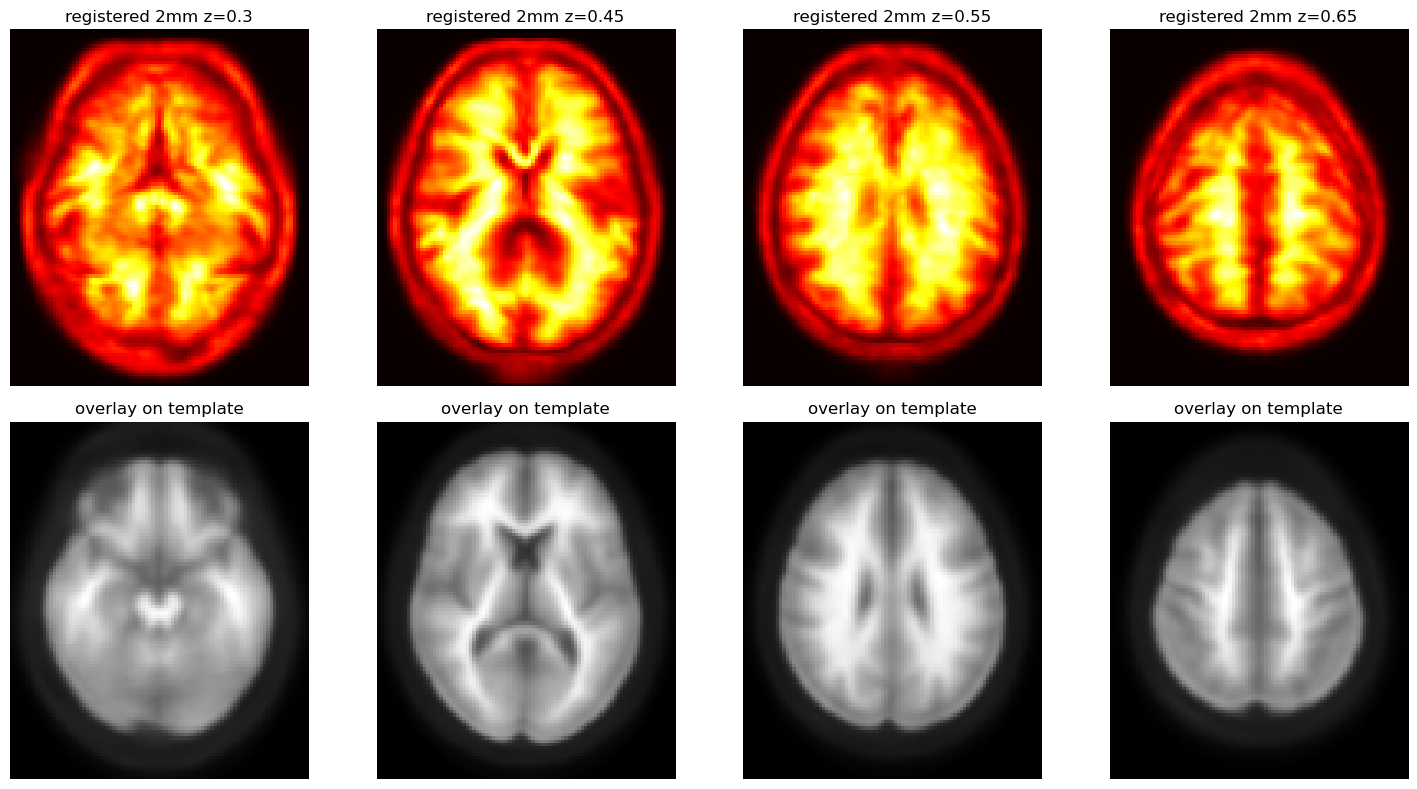

In [14]:
import numpy as np, matplotlib.pyplot as plt

w = reg["warpedmovout"].numpy()
t2 = template_2mm.numpy()

fig, ax = plt.subplots(2, 4, figsize=(15, 8))
fracs = [0.3, 0.45, 0.55, 0.65]
for i, fr in enumerate(fracs):
    z = int(w.shape[2]*fr)
    # registered image
    ax[0,i].imshow(np.rot90(w[:,:,z]), cmap="hot")
    ax[0,i].set_title(f"registered 2mm z={fr}"); ax[0,i].axis("off")
    # overlay on template
    ax[1,i].imshow(np.rot90(t2[:,:,z]), cmap="gray")
    ax[1,i].set_title("overlay on template"); ax[1,i].axis("off")
plt.tight_layout(); plt.show()

### Prepare 2mm artifacts — template, brain mask, cerebellum mask

In [15]:
import ants, numpy as np

# downsample template to 2mm (the registration target)
template_ants_1mm = ants.from_numpy(template.astype(np.float32),
                                    origin=mni.origin, spacing=mni.spacing, direction=mni.direction)
template_2mm = ants.resample_image(template_ants_1mm, (2,2,2), use_voxels=False, interp_type=0)
print("template 2mm:", template_2mm.shape)

# resample brain mask to 2mm (nearest-neighbor to keep it binary)
mask_ants = ants.from_numpy(mask.astype(np.float32),
                            origin=mni.origin, spacing=mni.spacing, direction=mni.direction)
mask_2mm = ants.resample_image(mask_ants, (2,2,2), use_voxels=False, interp_type=1).numpy() > 0.5
print("brain mask 2mm:", mask_2mm.shape, "voxels:", int(mask_2mm.sum()))

# resample cerebellum mask to 2mm
cereb_ants = ants.from_numpy(cereb_mask.astype(np.float32),
                             origin=mni.origin, spacing=mni.spacing, direction=mni.direction)
cereb_2mm = ants.resample_image(cereb_ants, (2,2,2), use_voxels=False, interp_type=1).numpy() > 0.5
print("cerebellum mask 2mm:", cereb_2mm.shape, "voxels:", int(cereb_2mm.sum()))

# save 2mm artifacts for workers
np.save("_pp_template2.npy", template_2mm.numpy().astype(np.float32))
np.save("_pp_mask2.npy", mask_2mm.astype(np.uint8))
np.save("_pp_cereb2.npy", cereb_2mm.astype(np.uint8))
print("\n2mm artifacts saved.")

template 2mm: (91, 109, 91)
brain mask 2mm: (91, 109, 91) voxels: 230077
cerebellum mask 2mm: (91, 109, 91) voxels: 24414

2mm artifacts saved.


### Verify 2mm artifacts — template + brain & cerebellum masks

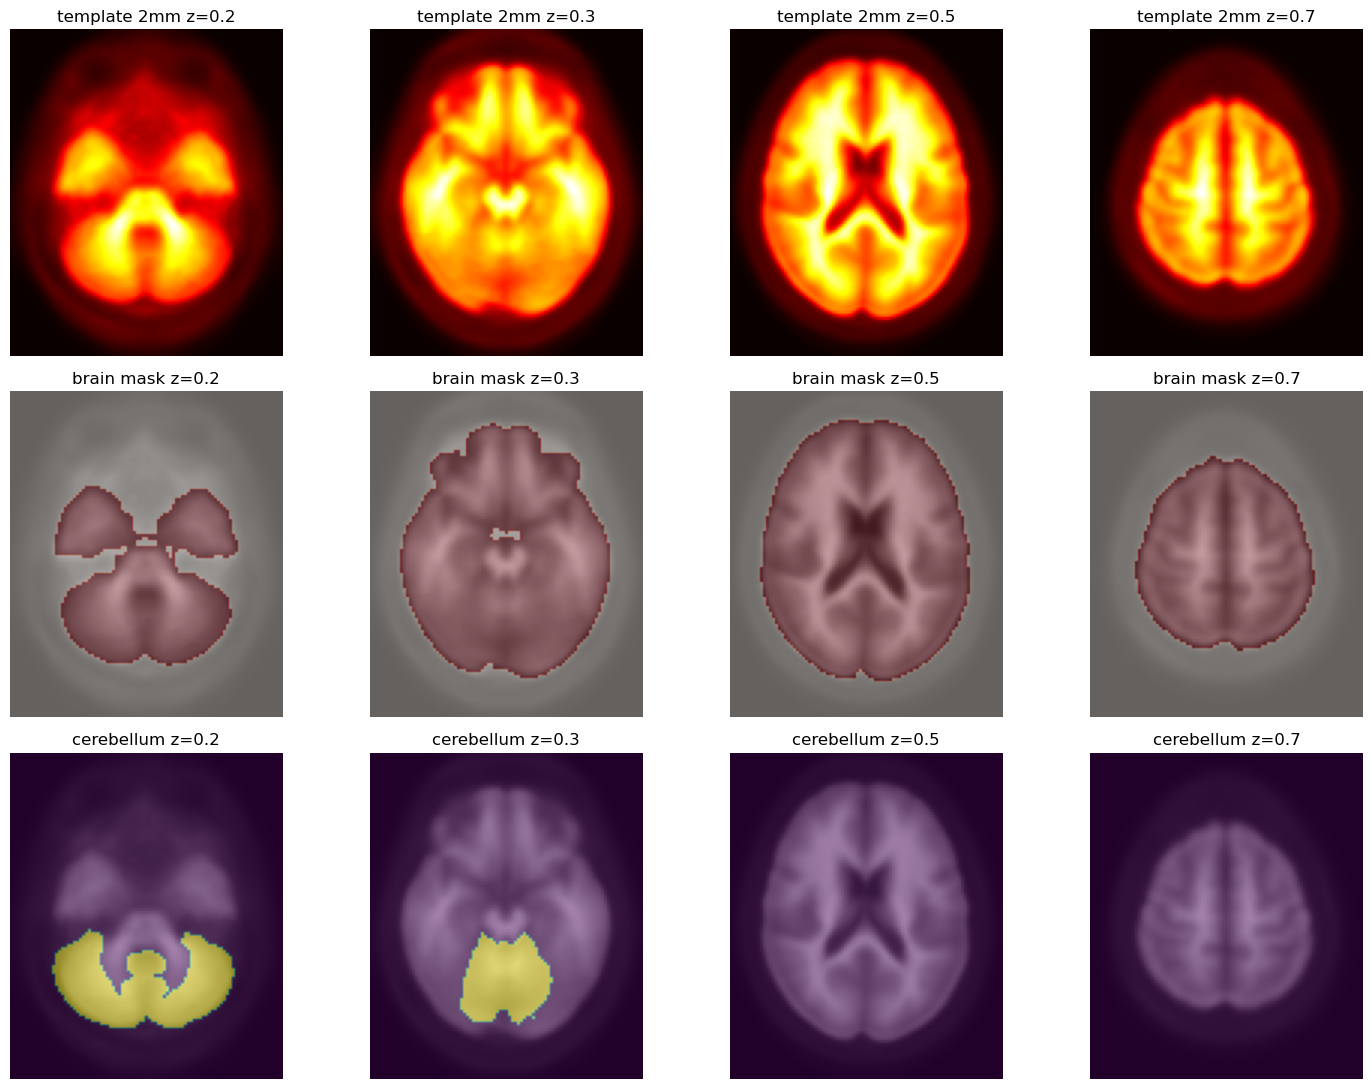

In [18]:
import matplotlib.pyplot as plt, numpy as np

t2 = template_2mm.numpy()
nz = t2.shape[2]
fracs = [0.2, 0.3, 0.5, 0.7]

fig, ax = plt.subplots(3, 4, figsize=(15, 11))
# row 0: 2mm template
for i, fr in enumerate(fracs):
    z = int(nz*fr)
    ax[0,i].imshow(np.rot90(t2[:,:,z]), cmap="hot")
    ax[0,i].set_title(f"template 2mm z={fr}"); ax[0,i].axis("off")
# row 1: brain mask on template
for i, fr in enumerate(fracs):
    z = int(nz*fr)
    ax[1,i].imshow(np.rot90(t2[:,:,z]), cmap="gray")
    ax[1,i].imshow(np.rot90(mask_2mm[:,:,z]), cmap="Reds", alpha=0.4)
    ax[1,i].set_title(f"brain mask z={fr}"); ax[1,i].axis("off")
# row 2: cerebellum mask on template
for i, fr in enumerate(fracs):
    z = int(nz*fr)
    ax[2,i].imshow(np.rot90(t2[:,:,z]), cmap="gray")
    ax[2,i].imshow(np.rot90(cereb_2mm[:,:,z]), alpha=0.5)
    ax[2,i].set_title(f"cerebellum z={fr}"); ax[2,i].axis("off")
plt.tight_layout(); plt.show()

### Test — parallelism check at 2mm (2 vs 3 workers)

In [20]:
import os, time
import numpy as np, nibabel as nib, ants, re
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

os.environ["MNI_PATH_ENV"] = MNI_PATH
test_paths = [str(f) for f in sorted(Path("pp1_smooth").glob("*.nii.gz"))[:6]]

def reg_one(fpath):
    import os
    os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "1"
    os.environ["OMP_NUM_THREADS"] = "1"
    import numpy as np, nibabel as nib, ants, re
    from pathlib import Path
    template2 = np.load("_pp_template2.npy")
    t_ants = ants.from_numpy(template2, spacing=(2.0,2.0,2.0))
    img = nib.load(fpath); vox = img.header.get_zooms()[:3]
    moving = ants.from_numpy(img.get_fdata().astype(np.float32),
                             spacing=tuple(float(s) for s in vox))
    ants.registration(fixed=t_ants, moving=moving, type_of_transform="SyN")
    return 1

for w in [2, 3]:
    t0 = time.time()
    with ProcessPoolExecutor(max_workers=w) as ex:
        list(ex.map(reg_one, test_paths))
    el = time.time()-t0
    print(f"{w} workers: {el:.0f}s total ({el/6:.0f}s/img)", flush=True)

2 workers: 58s total (10s/img)
3 workers: 56s total (9s/img)


### Final - Registration to FBP template (2mm, sequential, all 1499)

In [22]:
import time, numpy as np, nibabel as nib, ants, re
from pathlib import Path

Path("pp3_register").mkdir(exist_ok=True)
template2 = np.load("_pp_template2.npy")
t_ants = ants.from_numpy(template2, spacing=(2.0,2.0,2.0))

paths = sorted(Path("pp1_smooth").glob("*.nii.gz"))
N = len(paths); t0 = time.time(); done = skip = 0

for i, f in enumerate(paths, 1):
    iid = re.search(r"(I\d+)", f.name).group(1)
    out = Path("pp3_register")/f"{iid}.nii.gz"
    if out.exists():
        skip += 1
        print(f"[{i}/{N}] SKIP  {iid}", flush=True)
        continue
    print(f"[{i}/{N}] START {iid} ...", flush=True)
    ts = time.time()
    img = nib.load(str(f)); vox = img.header.get_zooms()[:3]
    moving = ants.from_numpy(img.get_fdata().astype(np.float32),
                             spacing=tuple(float(s) for s in vox))
    reg = ants.registration(fixed=t_ants, moving=moving, type_of_transform="SyN")
    nib.save(nib.Nifti1Image(reg["warpedmovout"].numpy().astype(np.float32), np.eye(4)), str(out))
    done += 1
    el = time.time()-t0
    eta = (el/done)*(N-i)/60
    print(f"[{i}/{N}] DONE  {iid} ({time.time()-ts:.0f}s) | total {el/60:.0f}min | ETA {eta:.0f}min", flush=True)

print(f"\nREGISTER FINISHED: {done} done, {skip} skipped, {(time.time()-t0)/60:.0f} min")

[1/1499] START I1002166 ...
[1/1499] DONE  I1002166 (12s) | total 0min | ETA 309min
[2/1499] START I1002693 ...
[2/1499] DONE  I1002693 (8s) | total 0min | ETA 248min
[3/1499] START I1004126 ...
[3/1499] DONE  I1004126 (10s) | total 0min | ETA 247min
[4/1499] START I1007969 ...
[4/1499] DONE  I1007969 (7s) | total 1min | ETA 231min
[5/1499] START I1008812 ...
[5/1499] DONE  I1008812 (7s) | total 1min | ETA 220min
[6/1499] START I1010826 ...
[6/1499] DONE  I1010826 (13s) | total 1min | ETA 237min
[7/1499] START I1012048 ...
[7/1499] DONE  I1012048 (7s) | total 1min | ETA 228min
[8/1499] START I1015965 ...
[8/1499] DONE  I1015965 (7s) | total 1min | ETA 223min
[9/1499] START I1016184 ...
[9/1499] DONE  I1016184 (10s) | total 1min | ETA 224min
[10/1499] START I1018497 ...
[10/1499] DONE  I1018497 (9s) | total 2min | ETA 224min
[11/1499] START I1020134 ...
[11/1499] DONE  I1020134 (8s) | total 2min | ETA 222min
[12/1499] START I1020509 ...
[12/1499] DONE  I1020509 (8s) | total 2min | ETA 2

## Step 4 - Brain masking

In [23]:
import numpy as np, nibabel as nib, re
from pathlib import Path

Path("pp4_mask").mkdir(exist_ok=True)
mask2 = np.load("_pp_mask2.npy").astype(bool)

paths = sorted(Path("pp3_register").glob("*.nii.gz"))
for i, f in enumerate(paths, 1):
    iid = re.search(r"(I\d+)", f.name).group(1)
    out = Path("pp4_mask")/f"{iid}.nii.gz"
    if out.exists(): continue
    img = nib.load(str(f)); v = img.get_fdata().astype(np.float32) * mask2
    nib.save(nib.Nifti1Image(v, img.affine), str(out))
    if i % 200 == 0: print(f"  masked {i}/{len(paths)}", flush=True)
print(f"MASK FINISHED: {len(list(Path('pp4_mask').glob('*.nii.gz')))} images")

  masked 200/1499
  masked 400/1499
  masked 600/1499
  masked 800/1499
  masked 1000/1499
  masked 1200/1499
  masked 1400/1499
MASK FINISHED: 1499 images


## Step 5 - Cerebellar SUVR normalisation (final)

  SUVR 200/1499
  SUVR 400/1499
  SUVR 600/1499
  SUVR 800/1499
  SUVR 1000/1499
  SUVR 1200/1499
  SUVR 1400/1499
SUVR FINISHED: 1499 images | fails: 0


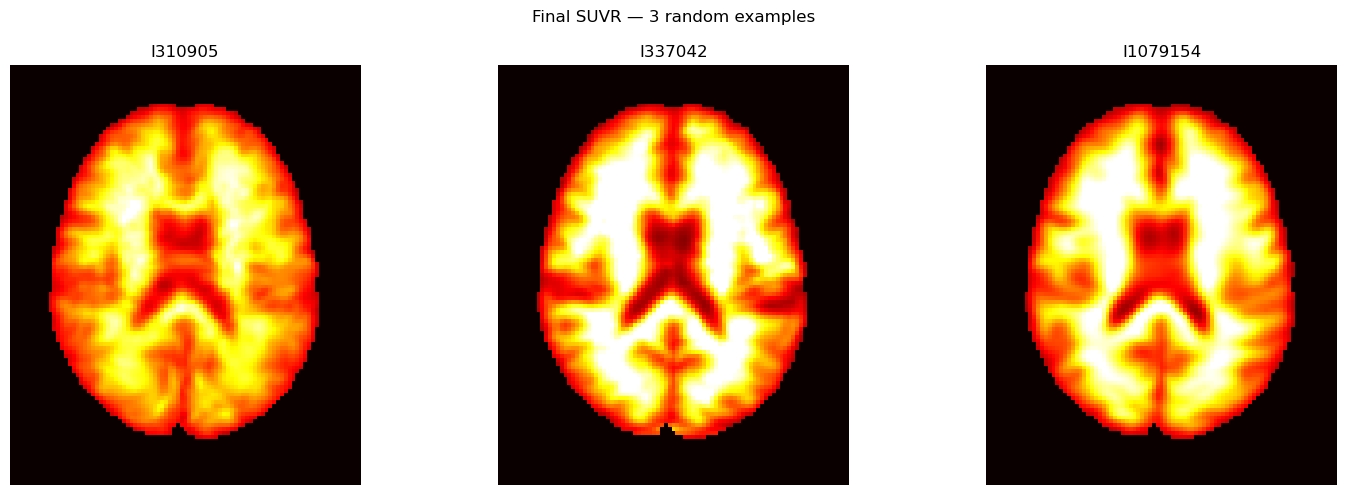

In [24]:
import numpy as np, nibabel as nib, re
from pathlib import Path
import matplotlib.pyplot as plt, random

Path("pp5_suvr").mkdir(exist_ok=True)
cereb2 = np.load("_pp_cereb2.npy").astype(bool)

paths = sorted(Path("pp4_mask").glob("*.nii.gz"))
fails = []
for i, f in enumerate(paths, 1):
    iid = re.search(r"(I\d+)", f.name).group(1)
    out = Path("pp5_suvr")/f"{iid}.nii.gz"
    if out.exists(): continue
    img = nib.load(str(f)); v = img.get_fdata().astype(np.float32)
    cm = v[cereb2].mean()
    if cm <= 0: fails.append(iid); continue
    nib.save(nib.Nifti1Image((v/cm).astype(np.float32), img.affine), str(out))
    if i % 200 == 0: print(f"  SUVR {i}/{len(paths)}", flush=True)

print(f"SUVR FINISHED: {len(list(Path('pp5_suvr').glob('*.nii.gz')))} images | fails: {len(fails)}")
if fails: print("  cereb-zero fails:", fails[:20])

# display 3 random final results
fs = sorted(Path("pp5_suvr").glob("*.nii.gz"))
random.seed(0); pick = random.sample(fs, 3)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, f in zip(ax, pick):
    v = nib.load(str(f)).get_fdata(); z = v.shape[2]//2
    im = a.imshow(np.rot90(v[:,:,z]), cmap="hot", vmin=0, vmax=2.5)
    a.set_title(re.search(r"(I\d+)", f.name).group(1)); a.axis("off")
plt.suptitle("Final SUVR — 3 random examples"); plt.tight_layout(); plt.show()

## Sanity Check

In [25]:
from pathlib import Path
for folder in ["pp1_smooth", "pp3_register", "pp4_mask", "pp5_suvr"]:
    n = len(list(Path(folder).glob("*.nii.gz")))
    print(f"{folder}: {n}")

pp1_smooth: 1499
pp3_register: 1499
pp4_mask: 1499
pp5_suvr: 1499
